In [11]:
import yfinance as yf
import pandas as pd

In [6]:
ticker = yf.Ticker("SPY")
df_period = ticker.history(period = "1y",interval = "1d")

print(df_period[["Open","High","Low","Close","Volume"]])


                                 Open        High         Low       Close  \
Date                                                                        
2025-06-13 00:00:00-04:00  591.716886  595.028895  588.731094  590.233887   
2025-06-16 00:00:00-04:00  593.595298  597.599385  593.417285  595.849426   
2025-06-17 00:00:00-04:00  593.407431  594.929955  589.996520  590.757812   
2025-06-18 00:00:00-04:00  591.657490  594.405951  589.709786  590.668823   
2025-06-20 00:00:00-04:00  593.347107  594.418041  587.873516  589.281616   
...                               ...         ...         ...         ...   
2026-06-08 00:00:00-04:00  743.359985  745.340027  738.190002  739.219971   
2026-06-09 00:00:00-04:00  743.630005  746.900024  722.590027  737.049988   
2026-06-10 00:00:00-04:00  733.390015  738.380005  725.330017  725.429993   
2026-06-11 00:00:00-04:00  728.760010  740.000000  724.409973  737.760010   
2026-06-12 00:00:00-04:00  740.710022  744.440002  735.030029  741.750000   

In [9]:
df_period.to_csv("SPY_data.csv")


In [12]:
spy_data = pd.read_csv("SPY_data.csv")
spy_data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2025-06-13 00:00:00-04:00,591.716886,595.028895,588.731094,590.233887,89506000,0.000,0.0,0.0
1,2025-06-16 00:00:00-04:00,593.595298,597.599385,593.417285,595.849426,79984100,0.000,0.0,0.0
2,2025-06-17 00:00:00-04:00,593.407431,594.929955,589.996520,590.757812,82209400,0.000,0.0,0.0
3,2025-06-18 00:00:00-04:00,591.657490,594.405951,589.709786,590.668823,76605000,0.000,0.0,0.0
4,2025-06-20 00:00:00-04:00,593.347107,594.418041,587.873516,589.281616,94051400,1.761,0.0,0.0
...,...,...,...,...,...,...,...,...,...
246,2026-06-08 00:00:00-04:00,743.359985,745.340027,738.190002,739.219971,49319100,0.000,0.0,0.0
247,2026-06-09 00:00:00-04:00,743.630005,746.900024,722.590027,737.049988,87683500,0.000,0.0,0.0
248,2026-06-10 00:00:00-04:00,733.390015,738.380005,725.330017,725.429993,60341300,0.000,0.0,0.0
249,2026-06-11 00:00:00-04:00,728.760010,740.000000,724.409973,737.760010,86330500,0.000,0.0,0.0


In [14]:
spy_data.dtypes

Date              object
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
Dividends        float64
Stock Splits     float64
Capital Gains    float64
dtype: object

In [35]:
''''
df = pd.read_csv("SPY_data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Date"] = df["Date"].dt.tz_localize(None)

df.set.index("Date",inplace = True)
df.sort_index(inplace = True)
'''

'\'\ndf = pd.read_csv("SPY_data.csv")\ndf["Date"] = pd.to_datetime(df["Date"])\ndf["Date"] = df["Date"].dt.tz_localize(None)\n\ndf.set.index("Date",inplace = True)\ndf.sort_index(inplace = True)\n'

In [ ]:
import pandas as pd

df = pd.read_csv("SPY_data.csv")

df["Date"] = pd.to_datetime(df["Date"], utc=True)  # Using utc to handle timezone errors

month_data = df[(df["Date"].dt.year == 2026) & (df["Date"].dt.month == 5)]

print(df["Date"].dtype)

datetime64[ns, UTC]


In [50]:
import numpy as np

ratio = (month_data["Close"]/month_data["Open"])
#log_returns = m.log(ratio)  # math log work only on single float, but here it is vectorised series
log_returns = np.log(ratio)
log_returns

221   -0.000832
222   -0.002865
223    0.002767
224    0.007757
225   -0.004732
226    0.003654
227    0.003862
228    0.001749
229    0.005187
230    0.006060
231   -0.003538
232   -0.001596
233   -0.001430
234    0.007502
235    0.005508
236   -0.000804
237    0.000773
238   -0.000559
239    0.005781
240    0.000767
dtype: float64

In [47]:
print(df["Date"].dtype)

object


In [51]:
arithmetic_returns = ratio
arithmetic_returns

221    0.999168
222    0.997139
223    1.002771
224    1.007787
225    0.995279
226    1.003660
227    1.003870
228    1.001751
229    1.005200
230    1.006078
231    0.996468
232    0.998405
233    0.998571
234    1.007530
235    1.005524
236    0.999196
237    1.000773
238    0.999441
239    1.005798
240    1.000767
dtype: float64

Text(0, 0.5, 'Returns')

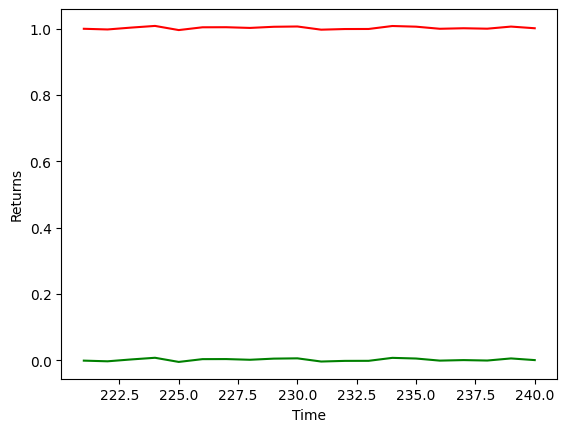

In [58]:
import matplotlib.pyplot as plt

plt.plot(log_returns,color = "green")
plt.plot(arithmetic_returns,color = "red")
plt.xlabel("Time")
plt.ylabel("Returns")


In [ ]:
# Calculating Variance, mean and Standard Deviation
import numpy as np
variance = log_returns.var()
std = log_returns.std()
mean = log_returns.mean()

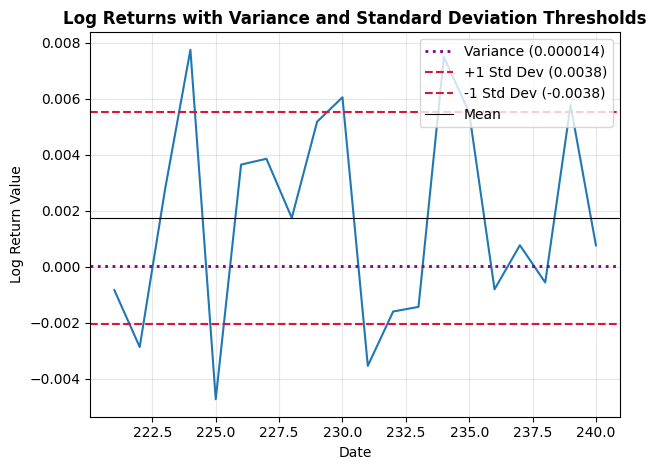

In [92]:
plt.plot(log_returns)
plt.axhline(y=variance, color="purple", linestyle=":", linewidth=2, label=f"Variance ({variance:.6f})")
plt.axhline(y=mean + std, color="crimson", linestyle="--", label=f"+1 Std Dev ({std:.4f})")
plt.axhline(y=mean - std, color="crimson", linestyle="--", label=f"-1 Std Dev (-{std:.4f})")
plt.axhline(y=mean, color="black", linestyle="-", linewidth=0.8, label="Mean")

plt.title("Log Returns with Variance and Standard Deviation Thresholds", fontsize=12, fontweight="bold")
plt.xlabel("Date", fontsize=10)
plt.ylabel("Log Return Value", fontsize=10)


plt.legend(loc="upper right") 
plt.grid(True, alpha=0.3)     
plt.tight_layout()
